In [9]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import datetime, os

%load_ext tensorboard

np.random.seed(42)

In [10]:
batch_size = 32
img_size = (240, 240)

# create a training dataset
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    '/content/drive/MyDrive/Colab Notebooks/shoes_data/hw5_dataset/train',
     shuffle=True, batch_size=batch_size, image_size=img_size,
    validation_split=0.2, subset='training', seed=42
)

# create a validation dataset
valid_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    '/content/drive/MyDrive/Colab Notebooks/shoes_data/hw5_dataset/train', 
    shuffle=True, batch_size=batch_size, image_size=img_size,
    validation_split=0.2, subset='validation', seed=42
)

# create a test dataset
test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    '/content/drive/MyDrive/Colab Notebooks/shoes_data/hw5_dataset/test', 
    shuffle=True, batch_size=batch_size, image_size=img_size
)

Found 711 files belonging to 3 classes.
Using 569 files for training.
Found 711 files belonging to 3 classes.
Using 142 files for validation.
Found 114 files belonging to 3 classes.


In [11]:
class_names = train_dataset.class_names
class_names


['adidas', 'converse', 'nike']

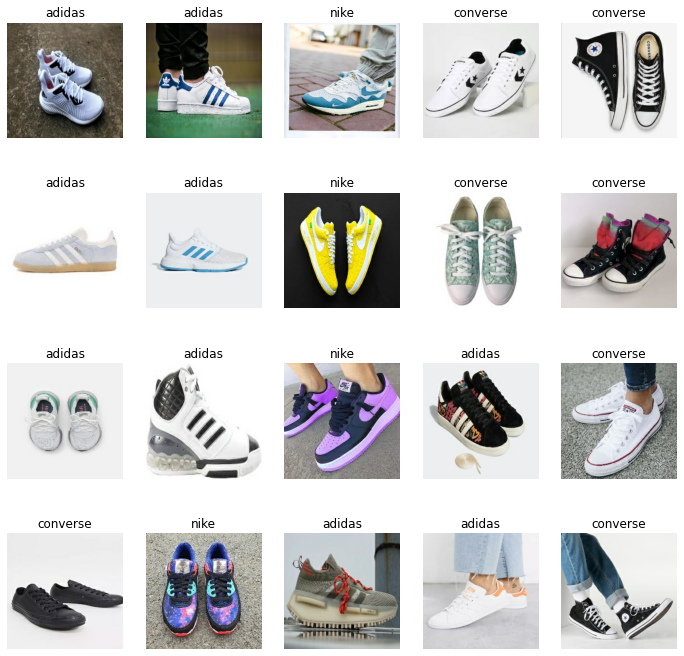

In [12]:
plt.figure(figsize=(12, 12))
for images, labels in train_dataset.take(1):
    for i in range(20):
        ax = plt.subplot(4, 5, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(train_dataset.class_names[labels[i]])
        plt.axis('off')


In [13]:
# load a base model
base_model = keras.applications.xception.Xception(input_shape=(224, 224, 3),
                                                  weights='imagenet',
                                                  include_top=False)


83683744/83683744 [==============================] - 2s 0us/step


In [14]:
from matplotlib.cbook import flatten
from tensorflow.keras.layers import MaxPooling2D
# create an input layer
input = keras.layers.Input(shape=(240, 240, 3))

# resize and preprocess input images
resized_input = keras.layers.Resizing(224, 224)(input)
preprocessed_input = keras.applications.xception.preprocess_input(resized_input)

# add data augmentation layers to reduce overfitting and make data more diverse
flip = keras.layers.RandomFlip('horizontal')(preprocessed_input)
rotation = keras.layers.RandomRotation(0.2)(flip)
zoom = keras.layers.RandomZoom(0.2)(rotation)

# run preprocessed images through the base model
base_model_output = base_model(zoom)

# add a GlobalAveragePooling layer and a dropout layer to reduce overfitting
avg = keras.layers.MaxPooling2D((4,4))(base_model_output)
dropout = keras.layers.Dropout(0.2)(avg)
flatten = keras.layers.Flatten()(avg)
# add a fully connected layer with 3 nodes since the dataset has 3 classes
output = keras.layers.Dense(3, activation='softmax')(dropout)

# create a model
model = keras.Model(inputs=input, outputs=output)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 240, 240, 3)]     0         
                                                                 
 resizing (Resizing)         (None, 224, 224, 3)       0         
                                                                 
 tf.math.truediv (TFOpLambda  (None, 224, 224, 3)      0         
 )                                                               
                                                                 
 tf.math.subtract (TFOpLambd  (None, 224, 224, 3)      0         
 a)                                                              
                                                                 
 random_flip (RandomFlip)    (None, 224, 224, 3)       0         
                                                                 
 random_rotation (RandomRota  (None, 224, 224, 3)      0     

In [15]:
# create a tensorboard callback to track accuracy and loss for different epochs
logdir = os.path.join("logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callback = tf.keras.callbacks.TensorBoard(logdir, histogram_freq=1)


In [16]:
for layer in base_model.layers:
    layer.trainable = False


In [ ]:
optimizer = keras.optimizers.Adam(learning_rate=0.0001)
model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer,
              metrics=['accuracy'])

history = model.fit(train_dataset, epochs=15, validation_data=valid_dataset,
                    callbacks=[tensorboard_callback])

Epoch 1/15


In [ ]:
%tensorboard --logdir logs

In [ ]:
# unfreeze pretrained layers
for layer in base_model.layers:
    layer.trainable = True

# create an early stopping callback
early_stopping_callback = keras.callbacks.EarlyStopping(
    patience=20, restore_best_weights=True)


In [ ]:
# decrease a learning rate and compile the model
optimizer = keras.optimizers.Adam(learning_rate=0.00001)
model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer,
              metrics=['accuracy'])

# continue learning
history2 = model.fit(train_dataset, epochs=16, 
                     initial_epoch=history.epoch[-1],
                     validation_data=valid_dataset,
                     callbacks=[tensorboard_callback, early_stopping_callback])


In [ ]:
%tensorboard --logdir logs

In [ ]:
model.evaluate(test_dataset)

In [ ]:
# take a batch of images from the test set and make a prediction
image_batch, label_batch = test_dataset.as_numpy_iterator().next()
predictions = model.predict_on_batch(image_batch)

# apply an argmax since the model
predictions = np.argmax(predictions, axis=-1)

# print predicted and real labels
print('Predictions:\n', predictions)
print('Labels:\n', label_batch)

# plot first 9 images with the predicted classes
plt.figure(figsize=(10, 10))
for i in range(9):
  ax = plt.subplot(3, 3, i + 1)
  plt.imshow(image_batch[i].astype("uint8"))
  plt.title(class_names[predictions[i]])
  plt.axis("off")
